In [1]:
import math
import tqdm
import torch
import gpytorch
from matplotlib import pyplot as plt
import scipy.io as sio
import numpy as np
import os
import torch.nn as nn
import numpy.linalg as LA
import ipdb
from torch.utils.data import TensorDataset, DataLoader
#import iri2016 as iri
#import iri2016.plots
from pyiri2016 import IRI2016
# Make plots inline
%matplotlib inline

smoke_test = ('CI' in os.environ)


660023
tensor(65.8718)
tensor(0.0406)
tensor([-74.5463,   0.7617,   8.6607,  -1.0300, -12.4000, 307.0000, -15.0000,
          1.0000])
torch.Size([2958111, 8])
torch.Size([2958111, 1])


<IPython.core.display.Javascript object>


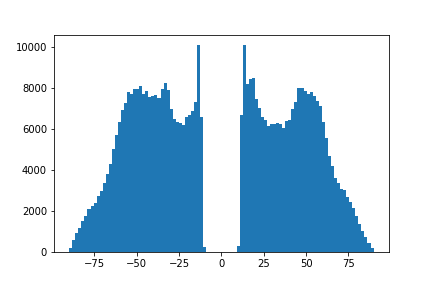

tensor(10.0766)
torch.Size([2373173, 8])
torch.Size([2373173, 1])
torch.Size([489919, 8])
torch.Size([95019, 8])


In [2]:
%matplotlib notebook

########################################## load the data ############
i = 0
#data = sio.loadmat('data/Delay/all_'+str(i)+'.mat')
data = sio.loadmat('data/Delay/330w_0_minutes_geom.mat')

ALT = data['out'][:,0]
mLat = data['out'][:,1]
#ipdb.set_trace()

mLon = data['out'][:,2]
UT = data['out'][:,3]
VTEC0 = data['out'][:,4]

varis = data['out'][:,5:9]
DoY = np.array(data['out'][:,9])
VTEC1 = data['out'][:,10]
NmF2 = data['out'][:,11]
year = data['out'][:,12]

Month = np.zeros(len(DoY))
DoM = np.zeros(len(DoY))
for i in range(len(DoY)):
    Month[i] = int(DoY[i])+1
    DoM[i] = int((DoY[i] - int(DoY[i]))*30)
LT = UT + mLon/15



Vari_idx = [1,2,3,5,6,7,8,9]
Target = [11]

ind = np.where((np.abs(mLat)>0) \
                   & (~np.isnan(varis[:,0])) \
                   #& (varis[:,0]>-30) \
                   & (~np.isnan(varis[:,1])) \
                   & (~np.isnan(varis[:,2])) \
                   & (~np.isnan(varis[:,3])) \
                   #& (varis[:,3]<120) \
                   & (ALT>200) \
                   & (ALT<400) \
                   & (NmF2>np.exp(9.5)) \
                   & (NmF2<np.exp(15))
                   & (VTEC0 < 60)
                   & (VTEC0 > 0)
                  )[0]

def seed_torch(seed):
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

#seed_torch(1029)



X = torch.from_numpy(data['out'][ind,:]).type( torch.FloatTensor )
#X[:,2] = torch.from_numpy(LT[ind])

#Y = torch.from_numpy(np.sqrt(data['out'][ind,16]/(1.24e4))).type( torch.FloatTensor )
Y = torch.from_numpy(data['out'][ind,:]).type( torch.FloatTensor )
Y = Y[:,Target]

X[:,0] = np.cos(X[:,0]*np.pi/180)
#X[:,1] = np.sin(X[:,1]*np.pi/180)
X[:,2] = np.sin(X[:,2]*np.pi/24)
X[:,9] = np.sin(X[:,9]*np.pi/365)

ind_vtec = np.where((VTEC1[ind]>0) \
                     & (VTEC1[ind]<VTEC0[ind]/20))[0]
print(len(ind_vtec))
X[ind_vtec,4] = X[ind_vtec,4]+X[ind_vtec,10]
X[~ind_vtec,4] = X[~ind_vtec,4]*1.05

print(X[:,4].max())
print(X[:,4].min())

X = X[:,Vari_idx]

X_save = X
Y_save = Y

#Y = (Y - Y_save.min())/(Y_save.max()-Y_save.min())

Ref = data['out'][ind,12]


### Normlisation
#X = X/LA.norm(X)
#Y = Y/LA.norm(Y)

print(X[1,:])

print(X.shape)
print(Y.shape)

idx_train = np.where((Ref!=2009) & (Ref!=2014))[0]
idx_test = np.where((Ref==2009) | (Ref==2014))[0]
idx_test1 = np.where((Ref==2009))[0]
idx_test2 = np.where((Ref==2014))[0]

idx_test_t = idx_test2
#train_n = int(0.8 * len(X))
train_x = X[idx_train, :].contiguous()
train_y = Y[idx_train].contiguous()

test_x1 = X[idx_test1, :].contiguous()
test_y1 = Y[idx_test1].contiguous()
test_x2 = X[idx_test2, :].contiguous()
test_y2 = Y[idx_test2].contiguous()

plt.hist(test_x1[:,0],100)
plt.show()
print(np.abs(test_x1[:,0]).min())

'''
batch_size = 256
train_x = train_x[0:int(len(idx_train)/batch_size)*batch_size,:].view(
                [batch_size, int(len(idx_train)/batch_size),\
                len(Vari_idx)])
train_y = train_y[0:int(len(idx_train)/batch_size)*batch_size].view(
                [batch_size,int(len(idx_train)/batch_size)])

test_x = test_x[0:int(len(idx_test_t)/batch_size)*batch_size,:].view(
                [batch_size, int(len(idx_test_t)/batch_size),\
                len(Vari_idx)])
test_y = test_y[0:int(len(idx_test_t)/batch_size)*batch_size].view(
                [batch_size,int(len(idx_test_t)/batch_size)])

if torch.cuda.is_available():
    test_x1, test_y1, test_x2, test_y2 =\
    test_x1.cuda(), test_y1.cuda(),\
    test_x2.cuda(), test_y2.cuda(),
'''
print(train_x.shape)
print(train_y.shape)

print(test_x1.shape)
print(test_x2.shape)
#batch_num = torch.Size([train_x.shape[0]])
#print(batch_num)


In [14]:
from multiprocessing import cpu_count, Pool
from random import sample
import tqdm

cores = cpu_count()
print(cores)

def init():
    global varies
    global DoM
    global mLat
    global mLon
    global LT
    global Month
    global year

def generate_NmF2(idx):
    Obj = IRI2016()
    IRIData, IRIDATAAdd = Obj.IRI(ap=varis[idx,3], dom=DoM[idx],
                                  f107=varis[idx,3], glat=mLat[idx], glon=mLon[idx],
                                  hrlt=LT[idx], month=Month[idx], var=1, vbeg=130.,
                                  vend=130.+1., vstp=1., year=year[idx])

    return IRIDATAAdd['NmF2']/1e6

p = Pool(cores,init,())

NmF2 = []
for t in tqdm.tqdm(p.imap_unordered(generate_NmF2, idx_test1) \
                   , total=len(idx_test1)):
    #pass
    NmF2.append(t)

test_iri_y1 = torch.from_numpy(np.array(NmF2))

NmF2 = []
for t in tqdm.tqdm(p.imap_unordered(generate_NmF2, idx_test2) \
                   , total=len(idx_test2)):
    #pass
    NmF2.append(t)

test_iri_y2 = torch.from_numpy(np.array(NmF2))

    
RMSE_2009 = torch.sqrt(torch.mean((test_iri_y1 - test_y1.cpu())**2))
RMSE_2014 = torch.sqrt(torch.mean((test_iri_y2 - test_y2.cpu())**2))

print('Test RMSE in 2009: {}'.format(RMSE_2009))
print('Test RMSE in 2014: {}'.format(RMSE_2014)) 

8


  1%|          | 559/55536 [00:04<06:31, 140.57it/s]Process ForkPoolWorker-7:
Process ForkPoolWorker-3:
Process ForkPoolWorker-6:
Process ForkPoolWorker-4:
Process ForkPoolWorker-2:
Process ForkPoolWorker-8:


KeyboardInterrupt: 

Process ForkPoolWorker-1:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib64/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
Process ForkPoolWorker-5:
Traceback (most recent call last):
  File "/usr/lib64/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/usr/lib64/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/usr/lib64/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/usr/lib64/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/usr/lib64/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/usr/lib64/python3.7/multiprocessing/process.py", line 99, in run
    self._ta

In [3]:
from skorch import NeuralNetRegressor
from skorch.callbacks import ProgressBar, Checkpoint
from torch.nn import ReLU, Linear, Tanh, Sigmoid, LeakyReLU

data_dim = train_x.size(-1)

class MyModule(nn.Module):
    def __init__(self, num_units=10):
        super(MyModule, self).__init__()

        self.dense1 = Linear(data_dim, 32)
        self.dense2 = Linear(32, 16)
        self.dense3 = Linear(16, 8)
        self.nonlin = ReLU()
        self.output = nn.Linear(8, 1)

    def forward(self, X, **kwargs):
        X = self.nonlin(self.dense1(X))
        X = self.nonlin(self.dense2(X))
        X = self.nonlin(self.dense3(X))
        X = self.output(X)
        return X

my_callbacks = [Checkpoint()]
if True:
    my_callbacks.append(ProgressBar())

class LargeFeatureExtractor(torch.nn.Sequential):
    def __init__(self):
        super(LargeFeatureExtractor, self).__init__()
        self.add_module('linear1', nn.Linear(data_dim, 100))
        self.add_module('relu1', nn.ReLU())
        self.add_module('linear2', nn.Linear(100, 100))
        self.add_module('relu2', nn.ReLU())
        self.add_module('linear3', nn.Linear(100, 50))
        self.add_module('relu3', nn.ReLU())
        self.add_module('linear4', nn.Linear(50, 2))

feature_extractor = LargeFeatureExtractor()

class GPRegressionModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super(GPRegressionModel, self).__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.GridInterpolationKernel(
                gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=2)),
                num_dims=2, grid_size=100
            )
            self.feature_extractor = feature_extractor

        def forward(self, x):
            # We're first putting our data through a deep net (feature extractor)
            # We're also scaling the features so that they're nice values
            projected_x = self.feature_extractor(x)
            projected_x = projected_x - projected_x.min(0)[0]
            projected_x = 2 * (projected_x / projected_x.max(0)[0]) - 1

            mean_x = self.mean_module(projected_x)
            covar_x = self.covar_module(projected_x)
            return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.metrics.scorer module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.metrics. Anything that cannot be imported from sklearn.metrics is now part of the private API.
  warnings.warn(message, FutureWarning)


In [4]:
training_iterations = 2 if smoke_test else 100

iterator = tqdm.tqdm_notebook(range(training_iterations))

def train_GP(train_x, train_y, 
             test_x_high, test_y_high, 
             test_x_low, test_y_low, 
             model, likelihood,
             iteration, optimizer,
             save_name):
    
    # Find optimal model hyperparameters
    out_test = np.zeros(training_iterations)
    out_test_low = np.zeros(training_iterations)
    out_test_high = np.zeros(training_iterations)
    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(
        likelihood, model)
        
    for i in iterator:
                
        model.train()
        likelihood.train()

        # Zero backprop gradients
        optimizer.zero_grad()
        # Get output from model
        #ipdb.set_trace()
        
        output = model(train_x)
        # Calc loss and backprop derivatives
        loss = -mll(output, train_y)
        #ipdb.set_trace()
        loss.backward()
        iterator.set_postfix(loss=loss.item())
        optimizer.step()
        
        model.eval()
        likelihood.eval()
        with torch.no_grad(), gpytorch.settings.use_toeplitz(False), gpytorch.settings.fast_pred_var():
            #ipdb.set_trace()
            preds_high = model(test_x_high)
            preds_low = model(test_x_low)
        
        out_test_low[i] = torch.sqrt(torch.mean((preds_low.mean - test_y_low)**2))
        out_test_high[i] = torch.sqrt(torch.mean((preds_high.mean - test_y_high)**2))
        out_test[i] = torch.sqrt(torch.mean((preds_low.mean - test_y_low)**2)) \
                          +torch.sqrt(torch.mean((preds_high.mean - test_y_high)**2)) 
        out_test_diff = np.diff(out_test)
        
        if i>1: 
            if out_test[0:i].min() > out_test[i]:
                state_dict = model.state_dict()
                likelihood_state_dict = likelihood.state_dict()
                torch.save({'model': state_dict,\
                            'likelihood': likelihood_state_dict},\
                             save_name)
        #print('Test MAE: {}'.format(torch.mean(torch.abs(preds.mean - test_y))))
        #print('Test RMSE: {}'.format(out_test[i]))
        
        if i>5 & (out_test_diff[i-5:i]>=0).sum()==5:
            break
    #ipdb.set_trace()
    return out_test_low[0:i].min(), out_test_high[0:i].min() 
        


In [5]:
import pickle
from progressbar import progressbar
y_save = train_y
#Train_y = (train_y - train_y.min())/(train_y.max() - train_y.min())
Train_y = np.array(train_y)
print(train_x.shape)
print(train_y.shape)
print(train_y.max())
print(train_y.min())

lat_interval = 30
t_interval = 0.5
buffer = 5
lat_range = range(-90,90,lat_interval)
t_range = range(0,int(1/t_interval))
p = progressbar

RMSE_2009_NN = np.zeros([int(180/lat_interval),int(1/t_interval)])
RMSE_2014_NN = np.zeros([int(180/lat_interval),int(1/t_interval)])
RMSE_2009_GP = np.zeros([int(180/lat_interval),int(1/t_interval)])
RMSE_2014_GP = np.zeros([int(180/lat_interval),int(1/t_interval)])
Re_2009_NN = np.zeros([int(180/lat_interval),int(1/t_interval)])
Re_2014_NN = np.zeros([int(180/lat_interval),int(1/t_interval)])

net = MyModule()


def init_weights(m):
    if type(m) == nn.Linear:
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

for lat_sta in p(lat_range):
    
    for LT_sta in t_range:
        
        net.apply(init_weights)
        Model = NeuralNetRegressor(
            net,
            max_epochs=500,
            lr=0.02,
            #train_split=None,
            batch_size=128,
            #callbacks=[ProgressBar()],
            callbacks=my_callbacks,
            optimizer=torch.optim.Adam,
            device='cuda',
            # Shuffle training data on each epoch
            iterator_train__shuffle=True,
        )

        idx_train = np.where((train_x[:,0]>lat_sta-buffer) \
                      & (train_x[:,0]<=lat_sta+lat_interval+buffer)\
                      & (train_x[:,2]>LT_sta*t_interval) \
                      & (train_x[:,2]<=(LT_sta+1)*t_interval)
                            )[0]
        idx_test1 = np.where((test_x1[:,0]>lat_sta) \
                      & (test_x1[:,0]<=lat_sta+lat_interval)\
                      & (test_x1[:,2]>LT_sta*t_interval) \
                      & (test_x1[:,2]<=(LT_sta+1)*t_interval)
                            )[0]
        idx_test2 = np.where((test_x2[:,0]>lat_sta) \
                      & (test_x2[:,0]<=lat_sta+lat_interval)\
                      & (test_x2[:,2]>LT_sta*t_interval) \
                      & (test_x2[:,2]<=(LT_sta+1)*t_interval)
                            )[0]
        #ipdb.set_trace()
        
        train_x_GP = train_x[idx_train].cuda()
        train_y_GP = torch.from_numpy(Train_y[idx_train].squeeze()).cuda()
        test_x1_GP = test_x1[idx_test1].cuda()
        test_y1_GP = test_y1[idx_test1].cuda()
        test_x2_GP = test_x2[idx_test2].cuda()
        test_y2_GP = test_y2[idx_test2].cuda()
        
        likelihood = gpytorch.likelihoods.GaussianLikelihood()
        model_GP = GPRegressionModel(train_x_GP,
                                     train_y_GP,
                                     likelihood)
        #ipdb.set_trace()
        # Use the adam optimizer
        optimizer = torch.optim.Adam([
            {'params': model_GP.feature_extractor.parameters()},
            {'params': model_GP.covar_module.parameters()},
            {'params': model_GP.mean_module.parameters()},
            {'params': model_GP.likelihood.parameters()},
        ], lr=0.02)


        if torch.cuda.is_available():
            model_GP = model_GP.cuda()
            likelihood = likelihood.cuda()
        
        #ipdb.set_trace()
        model_GP_name = 'NmF2_Model/GP_'\
                +str(lat_sta)\
                +'_'\
                +str(int(LT_sta*24*t_interval))\
                +'.dat'
        
        RMSE_2009_GP_t, RMSE_2014_GP_t = train_GP(train_x=train_x_GP, 
                   train_y=train_y_GP, 
                   model=model_GP, 
                   likelihood=likelihood,
                   iteration=iterator, 
                   optimizer=optimizer,
                   test_x_low=test_x1_GP,
                   test_y_low=test_y1_GP,
                   test_x_high=test_x2_GP,
                   test_y_high=test_y2_GP,
                   save_name=model_GP_name)
        
        RMSE_2009_GP[int((lat_sta+90)/lat_interval), LT_sta] = RMSE_2009_GP_t
        RMSE_2014_GP[int((lat_sta+90)/lat_interval), LT_sta] = RMSE_2014_GP_t

        Model.fit(train_x[idx_train],Train_y[idx_train].reshape(-1, 1))

        model_name = 'NmF2_Model/'+str(lat_sta)+'_'+str(int(LT_sta*24*t_interval))+'.pkl'

        # Load best parameters
        if True:
            Model.load_params(f_params='params.pt')

        Y_pred1 = torch.from_numpy(Model.predict(test_x1[idx_test1]))
        Y_pred2 = torch.from_numpy(Model.predict(test_x2[idx_test2]))
        RMSE_2009_NN[int((lat_sta+90)/lat_interval), LT_sta]\
        = torch.sqrt(torch.mean((Y_pred1.squeeze() - test_y1[idx_test1].cpu())**2))
        RMSE_2014_NN[int((lat_sta+90)/lat_interval), LT_sta]\
        = torch.sqrt(torch.mean((Y_pred2.squeeze() - test_y2[idx_test2].cpu())**2))
        Re_2009_NN[int((lat_sta+90)/lat_interval), LT_sta]\
        = torch.median(torch.abs(Y_pred1.squeeze() - test_y1[idx_test1].cpu())/test_y1[idx_test1].cpu())
        Re_2014_NN[int((lat_sta+90)/lat_interval), LT_sta]\
        = torch.median(torch.abs(Y_pred2.squeeze() - test_y2[idx_test2].cpu())/test_y2[idx_test2].cpu())
        print('near', lat_sta, ' Lat by', LT_sta*24*t_interval)
        print('Using simple NN, Test RMSE in ',
              '2009: {}'.format(RMSE_2009_NN[int((lat_sta+90)/lat_interval), LT_sta]))
        print('Using simple NN, Test RMSE in ',
              '2014: {}'.format(RMSE_2014_NN[int((lat_sta+90)/lat_interval), LT_sta]))
        print('Using KISS-GP, Test RMSE in ',
              '2009: {}'.format(RMSE_2009_GP[int((lat_sta+90)/lat_interval), LT_sta]))
        print('Using KISS-GP, Test RMSE in ',
              '2014: {}'.format(RMSE_2014_GP[int((lat_sta+90)/lat_interval), LT_sta]))
        # saving
        with open(model_name, 'wb') as f:
            pickle.dump(net, f)
        

N/A% (0 of 6) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--

torch.Size([2373173, 8])
torch.Size([2373173, 1])
tensor(3268538.5000)
tensor(13361.6064)


  epoch        train_loss        valid_loss    cp     dur
-------  ----------------  ----------------  ----  ------
      1  62630229862.0702  53688404921.6489     +  0.2725


      2  51494503843.5199  41624276261.1298     +  0.1009


      3  40045666786.8022  34128529861.3740     +  0.0992


...

    498  5184526184.8896  8133169812.4497        0.1515


    499  5211385440.1218  8199513927.6281        0.1511


    500  5231004639.9594  8399031073.7582        0.1524


100% (6 of 6) |##########################| Elapsed Time: 0:36:26 Time:  0:36:26


near 60  Lat by 12.0
Using simple NN, Test RMSE in  2009: 92814.75
Using simple NN, Test RMSE in  2014: 184079.015625
Using KISS-GP, Test RMSE in  2009: 87831.7890625
Using KISS-GP, Test RMSE in  2014: 179098.296875


In [6]:
print(RMSE_2009_NN)
print(RMSE_2009_GP)
print('NN:')
print('2009:',RMSE_2009_NN.reshape(1,-1).mean())
print('2014:',RMSE_2014_NN.reshape(1,-1).mean())
print('GP:')
print('2009:',RMSE_2009_GP.reshape(1,-1).mean())
print('2014:',RMSE_2014_GP.reshape(1,-1).mean())
print((RMSE_2009_NN - RMSE_2009_GP)/RMSE_2009_NN)

[[135553.421875  152529.375    ]
 [136084.71875   164817.       ]
 [105458.171875  126307.375    ]
 [ 80423.1953125  97933.375    ]
 [ 72982.7265625  91379.734375 ]
 [ 83700.6328125  92814.75     ]]
[[ 97511.7109375 112653.71875  ]
 [110295.7734375 126205.9453125]
 [ 94697.859375  107835.3984375]
 [ 77205.4375     91697.4921875]
 [ 68904.1015625  80317.96875  ]
 [ 85353.140625   87831.7890625]]
NN:
2009: 111665.373046875
2014: 228825.9296875
GP:
2009: 95042.52799479167
2014: 222287.5625
[[ 0.28063999  0.26142936]
 [ 0.18950655  0.23426621]
 [ 0.10203394  0.14624622]
 [ 0.04001032  0.06367475]
 [ 0.0558848   0.12105272]
 [-0.01974307  0.05368717]]


Test RMSE in low: 280661.3125
Test RMSE in high: 751787.6875
Test RMSE in low: 282418.46875
Test RMSE in high: 752323.4375
Test RMSE in low: 280672.6875
Test RMSE in high: 751766.875
Test RMSE in low: 280668.78125
Test RMSE in high: 751887.125
Test RMSE in low: 281674.65625
Test RMSE in high: 752187.625
Test RMSE in low: 281497.71875
Test RMSE in high: 752220.9375
Test RMSE in low: 282042.0625
Test RMSE in high: 751919.125
Test RMSE in low: 282696.15625
Test RMSE in high: 752596.625
Test RMSE in low: 282902.0625
Test RMSE in high: 752511.375
Test RMSE in low: 282703.6875
Test RMSE in high: 752895.3125
Test RMSE in low: 282886.0625
Test RMSE in high: 752508.0
Test RMSE in low: 282850.78125
Test RMSE in high: 752520.4375
Test RMSE in low: 282839.6875
Test RMSE in high: 752625.5
Test RMSE in low: 283193.09375
Test RMSE in high: 752449.125
Test RMSE in low: 283040.15625
Test RMSE in high: 752899.125
Test RMSE in low: 283058.40625
Test RMSE in high: 752972.3125
Test RMSE in low: 283184.2812

In [6]:
%matplotlib notebook

t = torch.load('dkl_cifar_checkpoint.dat')

model = GPRegressionModel(train_x,train_y,likelihood)
model.load_state_dict(t['model'])

#ipdb.set_trace()
model.eval()
likelihood.eval()
with torch.no_grad(), gpytorch.settings.use_toeplitz(False), gpytorch.settings.fast_pred_var():
        model = model.cuda()
        #ipdb.set_trace()
        preds_low = model(test_x1)
        preds_high = model(test_x2)
        
RMSE_low = torch.sqrt(torch.mean((preds_low.mean - test_y1)**2))
RMSE_high = torch.sqrt(torch.mean((preds_high.mean - test_y2)**2))
print('Test RMSE in 2009: {}'.format(RMSE_low))
print('Test RMSE in 2014: {}'.format(RMSE_high))

#print(test_y.shape)
#print(preds.variance.shape)

'''
plt.subplot(221)
plt.hist2d(test_y.cpu().numpy(),\
           np.abs(preds.variance.cpu().numpy()),\
           bins=(50, 50),\
           range=[[2, 15], \
                  [np.abs(preds.variance.cpu()).min(),\
                   np.abs(preds.variance.cpu()).max()]],\
           cmap=plt.cm.Reds)
plt.subplot(222)
plt.plot(test_y.cpu().numpy(),\
         np.abs(preds.mean.cpu().numpy()),\
         'r.')
plt.subplot(223)
plt.hist2d(test_x[:,0].cpu().numpy(),\
           np.abs(preds.variance.cpu().numpy()),\
           bins=(50, 50),\
           range=[[-90, 90], \
                  [np.abs(preds.variance.cpu()).min(),\
                   np.abs(preds.variance.cpu()).max()]],\
           cmap=plt.cm.Reds)
plt.subplot(224)
plt.hist2d(test_x[:,0].cpu().numpy(),\
           np.abs(preds.mean.cpu().numpy()),\
           bins=(50, 50),\
           range=[[-90, 90], [0, 15]],\
           cmap=plt.cm.Reds)

plt.show()
'''
print('Test STD in 2009:{}'.format(LA.norm(preds_low.variance.cpu().numpy())/np.sqrt(test_y1.shape)))
print('Test STD in 2014:{}'.format(LA.norm(preds_high.variance.cpu().numpy())/np.sqrt(test_y2.shape)))

Test RMSE in 2009: 87952.0859375
Test RMSE in 2014: 203070.28125
Test STD in 2009:[0.0002074]
Test STD in 2014:[0.01039213]


In [8]:
X_ISR = np.vstack([Ref[ind,0],Ref[ind,1],
                           Ref[ind,6],TEC,
                           X_omni,Deci_Month])

from multiprocessing import cpu_count, Pool
from random import sample
import tqdm
import pandas as pd

cores = cpu_count()
print(cores)

sta = ['Arecibo','Millstone Hill','Poker Flat']
situ = ['low','high']
period = [[50,100],[120,200]]

Data = ['../ISR/mat_f/Arecall_LT_ref.mat',
        '../ISR/mat_f/Millall_LT_ref.mat',
        '../ISR/mat_f/Poker_LT_ref.mat']
RMSE = np.zeros([len(Data),len(period)])
for i in range(len(Data)):
    for j in range(len(period)):
        data_t = sio.loadmat(Data[i])
        Ref = data_t['X_ref']
        X = data_t['X_temp']
        NmF2_isr = torch.from_numpy(np.exp(X[0,:]))
        F107 = torch.from_numpy(X[6,:]*1e22)

        Ref = pd.DataFrame(np.array(np.vstack([Ref,NmF2_isr,F107]).T),
                          columns=['Lat','Lon','Alt',
                                  'Year','Month','DoM',
                                   'LT','NmF2','F10.7'])
        #print(Ref)
        Ref = Ref.drop_duplicates(subset=['Year','Month','DoM',
                                   'LT']).values
        #print(Ref['Year'].shape)

        #ipdb.set_trace()
        ind = np.where((np.array(Ref[:,8])>period[j][0])\
                      & (np.array(Ref[:,8])<period[j][1]))[0]
        #print(len(ind))

        def init2():
            global Ref

        def generate_NmF2_ISR(idx):
            Obj = IRI2016()
            IRIData, IRIDATAAdd = Obj.IRI(dom=Ref[idx][5],
                                          glat=Ref[idx][0], 
                                          glon=Ref[idx][1],
                                          hrlt=Ref[idx][6], 
                                          month=Ref[idx][4], 
                                          var=1, vbeg=130.,
                                          vend=130.+1., vstp=1., 
                                          year=Ref[idx][3])

            return np.sqrt(IRIDATAAdd['NmF2']/1.24e10)


        p = Pool(cores,init2,())

        NmF2 = []
        for t in tqdm.tqdm(p.imap_unordered(generate_NmF2_ISR, ind) \
                           , total=len(ind)):
            #pass
            NmF2.append(t)

        test_iri_isr = torch.from_numpy(np.array(NmF2))
        
        ISR_NmF2 = np.sqrt(Ref[ind,7]/1.24e4)
        RMSE[i,j] = torch.sqrt(torch.mean((test_iri_isr - ISR_NmF2)**2))
        #ipdb.set_trace()

for j in range(len(period)):
    for i in range(len(Data)):
        print('Test RMSE in',situ[j],'at', sta[i],
              '{}'.format(RMSE[i,j]))

#print('Test RMSE globally', '{}'.format(RMSE.mean().mean))

8


100%|██████████| 2802/2802 [00:20<00:00, 136.16it/s]
0it [00:00, ?it/s]

Test RMSE in low at Arecibo 3.897422001619528
Test RMSE in low at Millstone Hill 2.330817342472461
Test RMSE in low at Poker Flat 1.1789983092141314
Test RMSE in high at Arecibo 5.341309767161403
Test RMSE in high at Millstone Hill 3.8090997545667653
Test RMSE in high at Poker Flat nan



Process ForkPoolWorker-78:
Process ForkPoolWorker-95:
Process ForkPoolWorker-65:
Process ForkPoolWorker-56:
Process ForkPoolWorker-66:
Process ForkPoolWorker-55:
Process ForkPoolWorker-88:
Process ForkPoolWorker-79:
Process ForkPoolWorker-63:
Process ForkPoolWorker-80:
Process ForkPoolWorker-68:
Process ForkPoolWorker-76:
Process ForkPoolWorker-85:
Process ForkPoolWorker-81:
Process ForkPoolWorker-73:
Process ForkPoolWorker-82:
Process ForkPoolWorker-86:
Process ForkPoolWorker-83:
Process ForkPoolWorker-53:
Process ForkPoolWorker-72:
Process ForkPoolWorker-77:
Process ForkPoolWorker-84:
Process ForkPoolWorker-50:
Process ForkPoolWorker-60:
Process ForkPoolWorker-64:
Process ForkPoolWorker-75:
Process ForkPoolWorker-69:
Process ForkPoolWorker-51:
Process ForkPoolWorker-61:
Process ForkPoolWorker-67:
Process ForkPoolWorker-58:
Process ForkPoolWorker-94:
Process ForkPoolWorker-91:
Process ForkPoolWorker-52:
Process ForkPoolWorker-57:
Process ForkPoolWorker-71:
Process ForkPoolWorker-93:


In [4]:
############## omni data read #####################
%matplotlib notebook

from datetime import datetime
from aidapy import load_data
import aidapy.aidaxr
import matplotlib.pyplot as plt
import pandas as pd


# Set the start and end date as year, month, day
t0 = datetime(1960, 1, 1)
t1 = datetime(2017, 12, 31)

xr_omni = load_data(mission='omni', start_time=t0, end_time=t1)
#xr_omni['all1'].graphical.peek()
#ts = load_data(mission='omni', start_time=t0, end_time=t1)

'''
for var in xr_omni['all1'].products.values:
    print("{:35} (unit: {})".format(var, xr_omni['all1'].attrs[var]))
'''
# Convert the time series data to pandas format
data_pd = xr_omni['all1'].to_pandas()
print(xr_omni.keys())
#ts.data['all1'].timeseries.values

KeysView(<xarray.Dataset>
Dimensions:   (products: 52, time1: 482113)
Coordinates:
  * products  (products) <U33 'Bartels Rotation Number' ... 'Magnetosonic Mach No.'
  * time1     (time1) datetime64[ns] 1963-01-01 ... 2017-12-31
Data variables:
    all1      (time1, products) float64 1.771e+03 nan nan nan ... -5.0 39.0 6.0
Attributes:
    mission:  omni)


In [5]:
############## read omni date #####################

from multiprocessing import Pool
from multiprocessing import Process
from time import time
import datetime as dt

features = ['DST Index',
            'AE Index',
            'ap index',
            'f10.7 index',
            'Kp',
            'Plasma Flow Speed',
            'Bx GSE, GSM',
            'By GSM',
            'Bz GSM']
#ts.data['time1'][1]

# global value
def init():
    global date
    date = xr_omni['time1']


    
def omni_read(ind):
    #global data 
    d_out = np.zeros(4,)
    time_index = date[ind]
    t = (time_index - np.datetime64('1970-01-01T00:00:00Z')) / np.timedelta64(1, 's')
    a = datetime.utcfromtimestamp(t)
    
    d_out[0] = int(int(a.year))
    d_out[1] = int(int(a.month))
    d_out[2] = int(int(a.day))
    d_out[3] = int(int(a.hour))
    #ipdb.set_trace()
    #print(type(d_out[0]))
    #print(type(d_out[1]))
    #print(type(d_out[2]))
    #print(type(d_out[3]))
    Omni_time = dt.datetime(int(d_out[0]),int(d_out[1])\
                            ,int(d_out[2]),int(d_out[3]))

    #return Omni_time
    return a.year, a.month, a.day, a.hour

if __name__ == '__main__':
    
    #global data  
    
    data = xr_omni['time1']
    start = time()
    pool = Pool(8,init,())
    #pool=Pool(8)
    
    index =  range(1,xr_omni['time1'].size)    
    print(index)
        
    date = pool.map(omni_read, index)
    print(date[1000])
    #date = np.array(date)

    end = time()
    print('running time: ', end-start)    

/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ipykernel_launcher.py:30: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ipykernel_launcher.py:30: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ipykernel_launcher.py:30: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ipykernel_launcher.py:30: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
/export/scratch2/andong/Workspace/Python/test/lib/python3.7/site-packages/ipykernel_launcher.py:30: DeprecationWarning: parsing timezone aware datetimes is deprecated; this

range(1, 482113)
(1963, 2, 11, 17)
running time:  37.77713084220886


In [6]:
print(np.array(date).shape)

(482112, 4)


In [8]:
from multiprocessing import cpu_count, Pool
from random import sample
import tqdm
import pandas as pd
import datetime as dt

cores = cpu_count()
print(cores)

sta = ['Arecibo','Millstone Hill','Poker Flat']
situ = ['low','high']
period = [[50,80],[150,200]]

Data = ['../ISR/mat_f/Arecall_LT_ref.mat',
        '../ISR/mat_f/Millall_LT_ref.mat',
        '../ISR/mat_f/Poker_LT_ref.mat']

RMSE_ISR_DKL = np.zeros([len(Data),len(period)])
for i in range(len(Data)):
    for j in range(len(period)):
        data_t = sio.loadmat(Data[i])
        Ref = data_t['X_ref']
        X = np.array(data_t['X_temp'])
            
        NmF2_isr = torch.from_numpy(np.exp(X[0,:]))
        F107 = torch.from_numpy(X[6,:]*1e22)

        Ref = pd.DataFrame(np.array(
            np.vstack([Ref,NmF2_isr,F107]).T),
                          columns=['Lat','Lon','Alt',
                                  'Year','Month','DoM',
                                   'LT','NmF2','F10.7'])
        #print(Ref)
        Ref = Ref.drop_duplicates(subset=['Year','Month','DoM',
                                   'LT']).values
        date_np = np.array(date)
        Ref_np = Ref
        Ref_np[:,6] = Ref_np[:,6] - Ref_np[:,1]/15
        for k in range(Ref_np.shape[0]):
            if Ref_np[k,6]>24:
                Ref_np[k,6] -= 24
            elif Ref_np[k,6]<0:
                Ref_np[k,6] += 24
            print('left: {}'.format(Ref.shape[0]-k))

            
        index_omni = np.zeros(Ref.shape[0])
        X_omni = np.zeros([Ref.shape[0],len(features)])
        for k in range(Ref.shape[0]):
            index_omni = np.where(
                (date_np[:,0] == Ref_np[k,3]) \
                & (date_np[:,1] == Ref_np[k,4]) \
                & (date_np[:,2] == Ref_np[k,5]) \
                & (date_np[:,3] == int(Ref_np[k,6]))
            )[0]
            X_omni[k] = np.array(xr_omni['all1'][index_omni].sel(
                products=features).values)

            print('left: {}'.format(Ref.shape[0]-k))
            
        #print(index_omni)
        
        #ipdb.set_trace()
        ind = np.where((np.array(Ref[:,8])>period[j][0])\
                      & (np.array(Ref[:,8])<period[j][1]))[0]
        #print(len(ind))

        def init2():
            global Ref

        def generate_TEC_ISR(idx):
            Obj = IRI2016()
            IRIData, IRIDATAAdd = Obj.IRI(dom=Ref[idx][5],
                                          glat=Ref[idx][0], 
                                          glon=Ref[idx][1],
                                          hrlt=Ref[idx][6], 
                                          month=Ref[idx][4], 
                                          var=1, vbeg=130.,
                                          vend=130.+1., vstp=1., 
                                          year=Ref[idx][3])

            return IRIDATAAdd['VTEC']/1e16


        p = Pool(cores,init2,())

        TEC = []
        for t in tqdm.tqdm(p.imap_unordered(generate_TEC_ISR, ind) \
                           , total=len(ind)):
            #pass
            TEC.append(t)
        
        
        TEC = torch.from_numpy(np.array(TEC))
        Deci_Month = Ref[ind,4]+Ref[ind,5]/30-1
        
        X_ISR = torch.from_numpy(np.vstack([Ref[ind,0].T,Ref[ind,1].T,
                           Ref[ind,6].T,np.array(TEC).T,
                           X_omni[ind].T,Deci_Month.T]).T)
        Y_ISR = torch.from_numpy(Ref[ind,7])
        
        X_ISR = X_ISR.type(torch.FloatTensor).cuda()
        Y_ISR = Y_ISR.type(torch.FloatTensor).cuda()
        #print(X_ISR.shape)
        #print(Y_ISR.shape)
        
        t = torch.load('dkl_cifar_checkpoint.dat')

        likelihood = gpytorch.likelihoods.GaussianLikelihood()
        model = GPRegressionModel(train_x,train_y,likelihood)
        model.load_state_dict(t['model'])
        likelihood.load_state_dict(t['likelihood'])

        #ipdb.set_trace()
        model.eval()
        likelihood.eval()
        pred = []
        with torch.no_grad(), gpytorch.settings.use_toeplitz(False), gpytorch.settings.fast_pred_var():
                model = model.cuda()
                #ipdb.set_trace()
                preds = model(X_ISR)
                #reds_high = model(test_x2)

        RMSE_ISR_DKL[i,j] = torch.sqrt(torch.mean((preds.mean - Y_ISR)**2))
        print('Test RMSE during {}'.format(situ[j]), 
              'solar activity period at {}'.format(sta[i]),
              'is: {}'.format(RMSE_ISR_DKL[i,j]))
       

8
left: 15184
left: 15183
left: 15182
left: 15181
left: 15180
left: 15179
left: 15178
left: 15177
left: 15176
left: 15175
left: 15174
left: 15173
left: 15172
left: 15171
left: 15170
left: 15169
left: 15168
left: 15167
left: 15166
left: 15165
left: 15164
left: 15163
left: 15162
left: 15161
left: 15160
left: 15159
left: 15158
left: 15157
left: 15156
left: 15155
left: 15154
left: 15153
left: 15152
left: 15151
left: 15150
left: 15149
left: 15148
left: 15147
left: 15146
left: 15145
left: 15144
left: 15143
left: 15142
left: 15141
left: 15140
left: 15139
left: 15138
left: 15137
left: 15136
left: 15135
left: 15134
left: 15133
left: 15132
left: 15131
left: 15130
left: 15129
left: 15128
left: 15127
left: 15126
left: 15125
left: 15124
left: 15123
left: 15122
left: 15121
left: 15120
left: 15119
left: 15118
left: 15117
left: 15116
left: 15115
left: 15114
left: 15113
left: 15112
left: 15111
left: 15110
left: 15109
left: 15108
left: 15107
left: 15106
left: 15105
left: 15104
left: 15103
left: 15102
le

left: 10614
left: 10613
left: 10612
left: 10611
left: 10610
left: 10609
left: 10608
left: 10607
left: 10606
left: 10605
left: 10604
left: 10603
left: 10602
left: 10601
left: 10600
left: 10599
left: 10598
left: 10597
left: 10596
left: 10595
left: 10594
left: 10593
left: 10592
left: 10591
left: 10590
left: 10589
left: 10588
left: 10587
left: 10586
left: 10585
left: 10584
left: 10583
left: 10582
left: 10581
left: 10580
left: 10579
left: 10578
left: 10577
left: 10576
left: 10575
left: 10574
left: 10573
left: 10572
left: 10571
left: 10570
left: 10569
left: 10568
left: 10567
left: 10566
left: 10565
left: 10564
left: 10563
left: 10562
left: 10561
left: 10560
left: 10559
left: 10558
left: 10557
left: 10556
left: 10555
left: 10554
left: 10553
left: 10552
left: 10551
left: 10550
left: 10549
left: 10548
left: 10547
left: 10546
left: 10545
left: 10544
left: 10543
left: 10542
left: 10541
left: 10540
left: 10539
left: 10538
left: 10537
left: 10536
left: 10535
left: 10534
left: 10533
left: 10532
left

left: 5615
left: 5614
left: 5613
left: 5612
left: 5611
left: 5610
left: 5609
left: 5608
left: 5607
left: 5606
left: 5605
left: 5604
left: 5603
left: 5602
left: 5601
left: 5600
left: 5599
left: 5598
left: 5597
left: 5596
left: 5595
left: 5594
left: 5593
left: 5592
left: 5591
left: 5590
left: 5589
left: 5588
left: 5587
left: 5586
left: 5585
left: 5584
left: 5583
left: 5582
left: 5581
left: 5580
left: 5579
left: 5578
left: 5577
left: 5576
left: 5575
left: 5574
left: 5573
left: 5572
left: 5571
left: 5570
left: 5569
left: 5568
left: 5567
left: 5566
left: 5565
left: 5564
left: 5563
left: 5562
left: 5561
left: 5560
left: 5559
left: 5558
left: 5557
left: 5556
left: 5555
left: 5554
left: 5553
left: 5552
left: 5551
left: 5550
left: 5549
left: 5548
left: 5547
left: 5546
left: 5545
left: 5544
left: 5543
left: 5542
left: 5541
left: 5540
left: 5539
left: 5538
left: 5537
left: 5536
left: 5535
left: 5534
left: 5533
left: 5532
left: 5531
left: 5530
left: 5529
left: 5528
left: 5527
left: 5526
left: 5525

left: 1757
left: 1756
left: 1755
left: 1754
left: 1753
left: 1752
left: 1751
left: 1750
left: 1749
left: 1748
left: 1747
left: 1746
left: 1745
left: 1744
left: 1743
left: 1742
left: 1741
left: 1740
left: 1739
left: 1738
left: 1737
left: 1736
left: 1735
left: 1734
left: 1733
left: 1732
left: 1731
left: 1730
left: 1729
left: 1728
left: 1727
left: 1726
left: 1725
left: 1724
left: 1723
left: 1722
left: 1721
left: 1720
left: 1719
left: 1718
left: 1717
left: 1716
left: 1715
left: 1714
left: 1713
left: 1712
left: 1711
left: 1710
left: 1709
left: 1708
left: 1707
left: 1706
left: 1705
left: 1704
left: 1703
left: 1702
left: 1701
left: 1700
left: 1699
left: 1698
left: 1697
left: 1696
left: 1695
left: 1694
left: 1693
left: 1692
left: 1691
left: 1690
left: 1689
left: 1688
left: 1687
left: 1686
left: 1685
left: 1684
left: 1683
left: 1682
left: 1681
left: 1680
left: 1679
left: 1678
left: 1677
left: 1676
left: 1675
left: 1674
left: 1673
left: 1672
left: 1671
left: 1670
left: 1669
left: 1668
left: 1667

left: 15161
left: 15160
left: 15159
left: 15158
left: 15157
left: 15156
left: 15155
left: 15154
left: 15153
left: 15152
left: 15151
left: 15150
left: 15149
left: 15148
left: 15147
left: 15146
left: 15145
left: 15144
left: 15143
left: 15142
left: 15141
left: 15140
left: 15139
left: 15138
left: 15137
left: 15136
left: 15135
left: 15134
left: 15133
left: 15132
left: 15131
left: 15130
left: 15129
left: 15128
left: 15127
left: 15126
left: 15125
left: 15124
left: 15123
left: 15122
left: 15121
left: 15120
left: 15119
left: 15118
left: 15117
left: 15116
left: 15115
left: 15114
left: 15113
left: 15112
left: 15111
left: 15110
left: 15109
left: 15108
left: 15107
left: 15106
left: 15105
left: 15104
left: 15103
left: 15102
left: 15101
left: 15100
left: 15099
left: 15098
left: 15097
left: 15096
left: 15095
left: 15094
left: 15093
left: 15092
left: 15091
left: 15090
left: 15089
left: 15088
left: 15087
left: 15086
left: 15085
left: 15084
left: 15083
left: 15082
left: 15081
left: 15080
left: 15079
left

...

left: 1749
left: 1748
left: 1747
left: 1746
left: 1745
left: 1744
left: 1743
left: 1742
left: 1741
left: 1740
left: 1739
left: 1738
left: 1737
left: 1736
left: 1735
left: 1734
left: 1733
left: 1732
left: 1731
left: 1730
left: 1729
left: 1728
left: 1727
left: 1726
left: 1725
left: 1724
left: 1723
left: 1722
left: 1721
left: 1720
left: 1719
left: 1718
left: 1717
left: 1716
left: 1715
left: 1714
left: 1713
left: 1712
left: 1711
left: 1710
left: 1709
left: 1708
left: 1707
left: 1706
left: 1705
left: 1704
left: 1703
left: 1702
left: 1701
left: 1700
left: 1699
left: 1698
left: 1697
left: 1696
left: 1695
left: 1694
left: 1693
left: 1692
left: 1691
left: 1690
left: 1689
left: 1688
left: 1687
left: 1686
left: 1685
left: 1684
left: 1683
left: 1682
left: 1681
left: 1680
left: 1679
left: 1678
left: 1677
left: 1676
left: 1675
left: 1674
left: 1673
left: 1672
left: 1671
left: 1670
left: 1669
left: 1668
left: 1667
left: 1666
left: 1665
left: 1664
left: 1663
left: 1662
left: 1661
left: 1660
left: 1659

left: 984
left: 983
left: 982
left: 981
left: 980
left: 979
left: 978
left: 977
left: 976
left: 975
left: 974
left: 973
left: 972
left: 971
left: 970
left: 969
left: 968
left: 967
left: 966
left: 965
left: 964
left: 963
left: 962
left: 961
left: 960
left: 959
left: 958
left: 957
left: 956
left: 955
left: 954
left: 953
left: 952
left: 951
left: 950
left: 949
left: 948
left: 947
left: 946
left: 945
left: 944
left: 943
left: 942
left: 941
left: 940
left: 939
left: 938
left: 937
left: 936
left: 935
left: 934
left: 933
left: 932
left: 931
left: 930
left: 929
left: 928
left: 927
left: 926
left: 925
left: 924
left: 923
left: 922
left: 921
left: 920
left: 919
left: 918
left: 917
left: 916
left: 915
left: 914
left: 913
left: 912
left: 911
left: 910
left: 909
left: 908
left: 907
left: 906
left: 905
left: 904
left: 903
left: 902
left: 901
left: 900
left: 899
left: 898
left: 897
left: 896
left: 895
left: 894
left: 893
left: 892
left: 891
left: 890
left: 889
left: 888
left: 887
left: 886
left: 885


left: 127
left: 126
left: 125
left: 124
left: 123
left: 122
left: 121
left: 120
left: 119
left: 118
left: 117
left: 116
left: 115
left: 114
left: 113
left: 112
left: 111
left: 110
left: 109
left: 108
left: 107
left: 106
left: 105
left: 104
left: 103
left: 102
left: 101
left: 100
left: 99
left: 98
left: 97
left: 96
left: 95
left: 94
left: 93
left: 92
left: 91
left: 90
left: 89
left: 88
left: 87
left: 86
left: 85
left: 84
left: 83
left: 82
left: 81
left: 80
left: 79
left: 78
left: 77
left: 76
left: 75
left: 74
left: 73
left: 72
left: 71
left: 70
left: 69
left: 68
left: 67
left: 66
left: 65
left: 64
left: 63
left: 62
left: 61
left: 60
left: 59
left: 58
left: 57
left: 56
left: 55
left: 54
left: 53
left: 52
left: 51
left: 50
left: 49
left: 48
left: 47
left: 46
left: 45
left: 44
left: 43
left: 42
left: 41
left: 40
left: 39
left: 38
left: 37
left: 36
left: 35
left: 34
left: 33
left: 32
left: 31
left: 30
left: 29
left: 28
left: 27
left: 26
left: 25
left: 24
left: 23
left: 22
left: 21
left: 20


100%|██████████| 3786/3786 [00:28<00:00, 134.41it/s]


RuntimeError: CUDA error: device-side assert triggered

In [34]:


print(Ref.shape)
print(Ref[ind].shape)
print(np.array(TEC).shape)
print(X_omni[ind].shape)
print(Deci_Month.shape)
X_ISR = torch.from_numpy(np.vstack([Ref[ind,0].T,Ref[ind,1].T,
                           Ref[ind,6].T,np.array(TEC).T,
                           X_omni[ind].T,Deci_Month.T]).T)
Y_ISR = torch.from_numpy(Ref[ind,7])

X_ISR = X_ISR.type(torch.FloatTensor).cuda()
Y_ISR = Y_ISR.type(torch.FloatTensor).cuda()

print(X_ISR.shape)
print(Y_ISR.shape)


(15184, 9)
(7627, 9)
(7627,)
(7627, 9)
(7627,)
torch.Size([7627, 14])
torch.Size([7627])


In [42]:
print(X_ISR.shape)

preds = model(X_ISR)


torch.Size([696, 14])


RuntimeError: cuda runtime error (710) : device-side assert triggered at /pytorch/aten/src/THC/THCCachingHostAllocator.cpp:278

In [35]:
%matplotlib notebook

t = torch.load('dkl_cifar_checkpoint.dat')

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = GPRegressionModel(train_x,train_y,likelihood)
model.load_state_dict(t['model'])
likelihood.load_state_dict(t['likelihood'])

#ipdb.set_trace()
model.eval()
likelihood.eval()
with torch.no_grad(), gpytorch.settings.use_toeplitz(False), gpytorch.settings.fast_pred_var():
        model = model.cuda()
        #ipdb.set_trace()
        preds = model(X_ISR)
        #reds_high = model(test_x2)
        
RMSE = torch.sqrt(torch.mean((preds.mean - Y_ISR)**2))
print('Test RMSE at ISR: {}'.format(RMSE))


Test RMSE at ISR: 764635.875
